In [31]:
#load dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("LR_Zomato (1).csv" , encoding='ISO-8859-1')

In [32]:
df.columns

Index(['RestaurantID', 'RestaurantName', 'CountryCode', 'City', 'Address',
       'Locality', 'LocalityVerbose', 'Longitude', 'Latitude', 'Cuisines',
       'Currency', 'Has_Table_booking', 'Has_Online_delivery',
       'Is_delivering_now', 'Switch_to_order_menu', 'Price_range', 'Votes',
       'Average_Cost_for_two', 'Rating'],
      dtype='object')

In [33]:
df.describe()

,RestaurantID,CountryCode,Longitude,Latitude,Price_range,Votes,Average_Cost_for_two,Rating
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1.804837,156.909748,1199.210763,2.891268
std,8.791521e+06,56.750546,41.467058,11.007935,0.905609,430.169145,16121.183073,1.128845
min,5.300000e+01,1.000000,-157.948486,-41.330428,1.000000,0.000000,0.000000,1.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,1.000000,5.000000,250.000000,2.500000
50%,6.004089e+06,1.000000,77.191964,28.570469,2.000000,31.000000,400.000000,3.200000
75%,1.835229e+07,1.000000,77.282006,28.642758,2.000000,131.000000,700.000000,3.700000
max,1.850065e+07,216.000000,174.832089,55.976980,4.000000,10934.000000,800000.000000,4.900000


In [34]:
#convert 'Average_Cost_for_two' to numeric by removing commas(if any) and converting to float
df['average_cost'] = df['Average_Cost_for_two'].astype(float)

#convert 'Rating' to numeric (already numeric but ensuring proper data type)
df['rating'] = pd.to_numeric(df['Rating'], errors='coerce')

#convert 'Votes' to an integer type for numerical analysis
df['votes'] = df['Votes'].astype(int)

In [35]:
#Basic exploratory data analysis(EDA)

#check for missing values in all columns
missing_values = df.isnull().sum()
print(missing_values)

RestaurantID            0
RestaurantName          0
CountryCode             0
City                    0
Address                 0
Locality                0
LocalityVerbose         0
Longitude               0
Latitude                0
Cuisines                9
Currency                0
Has_Table_booking       0
Has_Online_delivery     0
Is_delivering_now       0
Switch_to_order_menu    0
Price_range             0
Votes                   0
Average_Cost_for_two    0
Rating                  0
average_cost            0
rating                  0
votes                   0
dtype: int64


In [6]:
#checking unique values in categorical columns

unique_values = df.select_dtypes(include=['object']).nunique()
print(unique_values)

RestaurantName          7446
City                     141
Address                 8918
Locality                1208
LocalityVerbose         1265
Cuisines                1825
Currency                  12
Has_Table_booking          2
Has_Online_delivery        2
Is_delivering_now          2
Switch_to_order_menu       1
dtype: int64


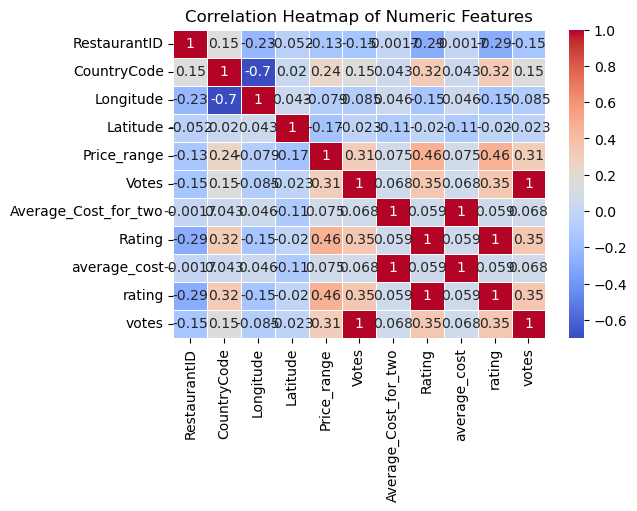

In [36]:
# Correlation heatmap of numeric features

# Select  only numeric columns for correlation heatmap
numeric_df = df.select_dtypes(include=['number'])

#Plot the correlation heatmap for numeric features 
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidth=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()




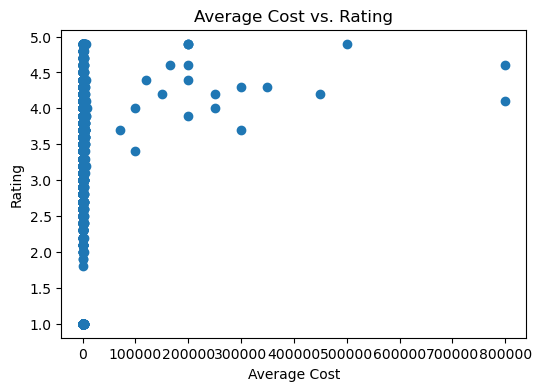

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(df['average_cost'], df['rating'])
plt.title('Average Cost vs. Rating')
plt.xlabel('Average Cost')
plt.ylabel('Rating')
plt.show()

In [37]:
#compute correlation of all numeric features with "Rating"

correlation_with_rating = df.select_dtypes(include=['number']).corr()['Rating'].sort_values(ascending=False)
print(correlation_with_rating)

rating                  1.000000
Rating                  1.000000
Price_range             0.462939
votes                   0.349105
Votes                   0.349105
CountryCode             0.319735
Average_Cost_for_two    0.058957
average_cost            0.058957
Latitude               -0.019806
Longitude              -0.145930
RestaurantID           -0.290381
Name: Rating, dtype: float64


In [38]:
#selected dependent and independent variables 

X = df[['average_cost', 'votes']]
y = df['rating']

In [39]:
#splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [40]:
#model training: LinearRegression()
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
#make predictions 
y_pred = model.predict(X_test)

print(y_pred)

[2.79059949 2.81919102 2.77457058 ... 2.750487   3.05081673 3.13420591]


In [42]:
#model evaluation metrics

mae = mean_absolute_error(y_test ,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 =r2_score(y_test, y_pred)

In [43]:
#display evaluation metrics  in a simple format
print("Model Evaluation metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE) : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-Squared (R2): {r2:.2f}")

Model Evaluation metrics:
Mean Absolute Error (MAE): 0.86
Mean Squared Error (MSE) : 1.11
Root Mean Squared Error (RMSE): 1.05
R-Squared (R2): 0.12


In [44]:
#residual analysis
residuals = y_test - y_pred

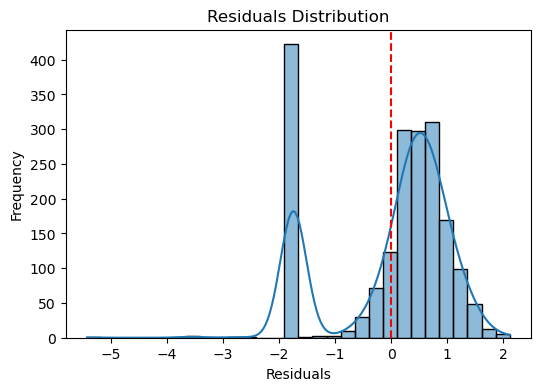

In [45]:
#Histogram of Residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals, bins=30 ,kde=True)
plt.axvline(x=0, color='red',linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

TypeError: min expected at least 1 argument, got 0

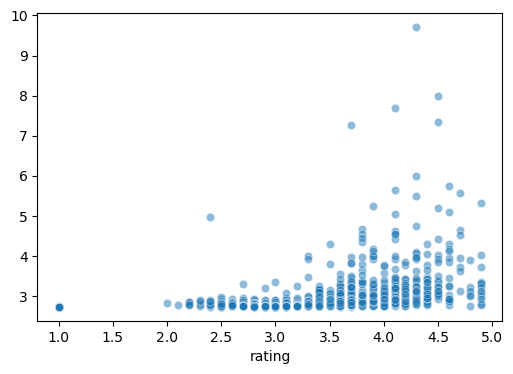

In [30]:
#observing actual vs predicted ratings
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test,min(),y_test.max()],[y_test.min(), y_test.max()],color="red", linestyle="--")
plt.title("actual vs predicted rating ")
plt.xlabel("actual ratings")
plt.ylabel("Predicted Ratings")
plt.show()